# 22 · Comparación visual e insights — EfficientNetV2L vs BirdNET V2.4

Visualizaciones comparativas entre el modelo del proyecto (**EfficientNetV2L**) y **BirdNET V2.4**
a nivel **global, por familia y por género**, más varios insights (concordancia de aciertos,
confianza vs. acierto, dónde gana cada modelo).

Todas las figuras usan la **paleta estándar del proyecto** (`src/viz_style.py`): EfficientNetV2L en azul
`#0173B2`, BirdNET en naranja `#DE8F05`, matrices de confusión en `YlOrRd`.

> **Kernel**: `.venv` del proyecto. **Requiere** haber ejecutado los notebooks 20 y 21
> (que generan `src/data/birdnet_vs_efficientnet_paired.csv`).

Salidas: figuras `fig/cmp_*.png|pdf` y tablas `src/data/birdnet_vs_efficientnet_by_species.csv` /
`..._global_metrics.csv`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix)

sys.path.append("../src")
import birdnet_utils as bu
import viz_style as vs
vs.apply_style()

ROOT = os.path.abspath(".."); DATA_DIR = os.path.join(ROOT, "src/data")
RES, BIRD = "EfficientNetV2L", "BirdNET_V2.4"
CR, CB = vs.MODEL_COLORS[RES], vs.MODEL_COLORS[BIRD]

comp = pd.read_csv(os.path.join(DATA_DIR, "birdnet_vs_efficientnet_paired.csv"))
for c in ("correct_effnet", "correct_birdnet"):
    if comp[c].dtype != bool:
        comp[c] = comp[c].astype(str).isin(["True", "true", "1", "1.0"])
gf = bu.get_genus_family_map()

print(f"grabaciones={len(comp)} | especies={comp.species_true.nunique()} "
      f"| familias={comp.family.nunique()} | géneros={comp.genus.nunique()}")
print(f"accuracy global -> EfficientNetV2L={comp.correct_effnet.mean():.3f} | BirdNET={comp.correct_birdnet.mean():.3f}")
comp.head()

grabaciones=11695 | especies=664 | familias=36 | géneros=301
accuracy global -> EfficientNetV2L=0.957 | BirdNET=0.903


,recording_id,species_true,species_pred_effnet,confidence_effnet,species_pred_birdnet,confidence_birdnet,correct_effnet,correct_birdnet,family,genus
0,100077,Dives warczewiczi,Dives warczewiczi,0.970769,Dives warczewiczi,0.057768,True,True,Icteridae,Dives
1,100089,Dolichonyx oryzivorus,Dolichonyx oryzivorus,0.915398,Dolichonyx oryzivorus,0.997286,True,True,Icteridae,Dolichonyx
2,100092,Thraupis episcopus,Thraupis episcopus,0.946251,Thraupis episcopus,0.836781,True,True,Thraupidae,Thraupis
3,100096,Dives warczewiczi,Dives warczewiczi,0.969514,Dives warczewiczi,0.999630,True,True,Icteridae,Dives
4,100097,Progne chalybea,Progne chalybea,0.983281,Progne chalybea,0.999784,True,True,Hirundinidae,Progne


In [2]:
comp.sort_values(by='correct_effnet', ascending=False)

,recording_id,species_true,species_pred_effnet,confidence_effnet,species_pred_birdnet,confidence_birdnet,correct_effnet,correct_birdnet,family,genus
0,100077,Dives warczewiczi,Dives warczewiczi,0.970769,Dives warczewiczi,0.057768,True,True,Icteridae,Dives
7709,501092,Molothrus bonariensis,Molothrus bonariensis,0.986087,Molothrus bonariensis,0.821617,True,True,Icteridae,Molothrus
7689,499437,Psarocolius viridis,Psarocolius viridis,0.992622,Psarocolius viridis,0.986821,True,True,Icteridae,Psarocolius
7690,49952,Thlypopsis sordida,Thlypopsis sordida,0.940354,Thlypopsis sordida,0.457452,True,True,Thraupidae,Thlypopsis
7691,499569,Synallaxis albescens,Synallaxis albescens,0.912794,Synallaxis albescens,0.994870,True,True,Furnariidae,Synallaxis
...,...,...,...,...,...,...,...,...,...,...
3287,249827,Hylophylax naevius,Myrmelastes leucostigma,0.534109,Lochmias nematura,0.308641,False,False,Thamnophilidae,Hylophylax
8943,61588,Grallaria varia,Herpsilochmus rufimarginatus,0.425239,Grallaria varia,0.987499,False,True,Grallaridae,Grallaria
3806,259542,Diglossa cyanea,Diglossa humeralis,0.285353,Diglossa cyanea,0.997912,False,True,Thraupidae,Diglossa
7507,47981,Glyphorynchus spirurus,Thamnophilus amazonicus,0.054108,Glyphorynchus spirurus,0.826129,False,True,Furnariidae,Glyphorynchus


## 1 · Panorama global

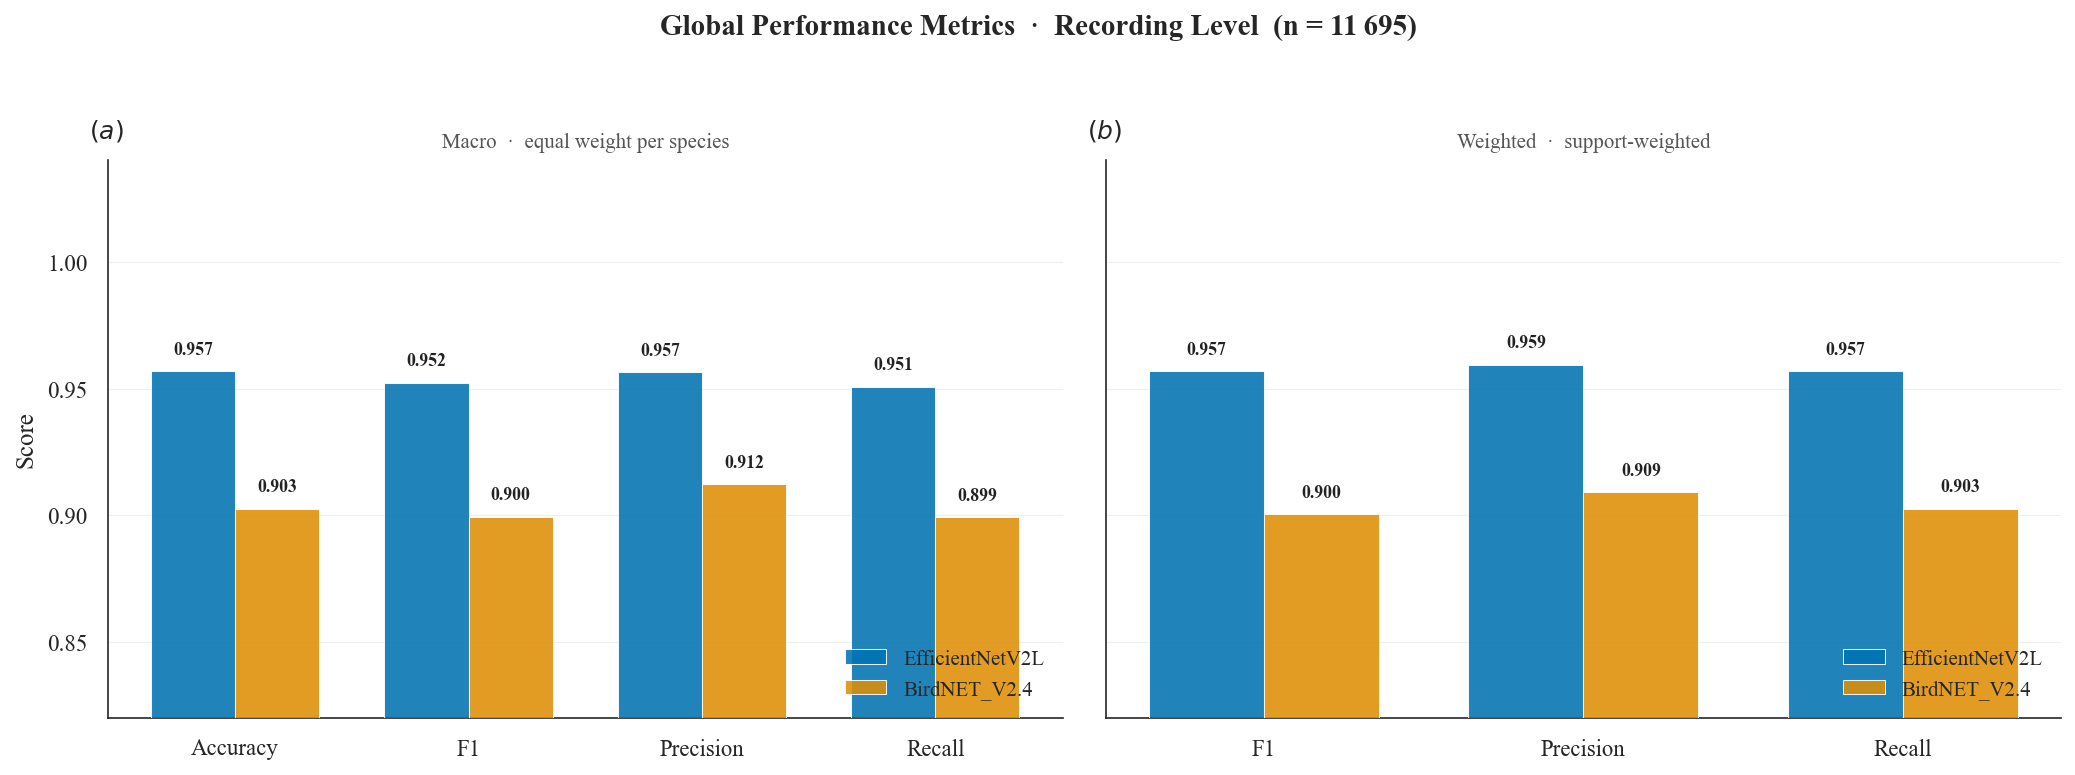

PR AUC   →  EfficientNetV2L: 0.9983  |  BirdNET: 0.9837
ROC AUC  →  EfficientNetV2L: 0.9672  |  BirdNET: 0.8813


,accuracy,f1_macro,precision_macro,recall_macro,f1_weighted,precision_weighted,recall_weighted,pr_auc,roc_auc
EfficientNetV2L,0.9569,0.9524,0.9566,0.9508,0.9570,0.9595,0.9569,0.9983,0.9672
BirdNET_V2.4,0.9027,0.8995,0.9122,0.8992,0.9005,0.9093,0.9027,0.9837,0.8813


In [3]:
# Global metrics — macro + weighted + PR AUC + ROC AUC
from sklearn.metrics import average_precision_score, roc_auc_score

def global_metrics(yt, yp):
    return {
        "accuracy":           accuracy_score(yt, yp),
        "f1_macro":           f1_score(yt, yp, average="macro",    zero_division=0),
        "precision_macro":    precision_score(yt, yp, average="macro",    zero_division=0),
        "recall_macro":       recall_score(yt, yp, average="macro",    zero_division=0),
        "f1_weighted":        f1_score(yt, yp, average="weighted", zero_division=0),
        "precision_weighted": precision_score(yt, yp, average="weighted", zero_division=0),
        "recall_weighted":    recall_score(yt, yp, average="weighted", zero_division=0),
    }

res_m  = global_metrics(comp.species_true, comp.species_pred_effnet)
bird_m = global_metrics(comp.species_true, comp.species_pred_birdnet)
summary = pd.DataFrame([res_m, bird_m], index=[RES, BIRD])

pr_auc_res   = average_precision_score(comp.correct_effnet.astype(int),  comp.confidence_effnet)
pr_auc_bird  = average_precision_score(comp.correct_birdnet.astype(int), comp.confidence_birdnet)
roc_auc_res  = roc_auc_score(comp.correct_effnet.astype(int),  comp.confidence_effnet)
roc_auc_bird = roc_auc_score(comp.correct_birdnet.astype(int), comp.confidence_birdnet)
summary["pr_auc"]  = [pr_auc_res,  pr_auc_bird]
summary["roc_auc"] = [roc_auc_res, roc_auc_bird]
summary.to_csv(os.path.join(DATA_DIR, "birdnet_vs_efficientnet_global_metrics.csv"))

macro_cols    = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]
macro_labels  = ["Accuracy", "F1", "Precision", "Recall"]
weighted_cols   = ["f1_weighted", "precision_weighted", "recall_weighted"]
weighted_labels = ["F1", "Precision", "Recall"]
res_macro   = [res_m[c]  for c in macro_cols]
bird_macro  = [bird_m[c] for c in macro_cols]
res_w       = [res_m[c]  for c in weighted_cols]
bird_w      = [bird_m[c] for c in weighted_cols]

_n = f"{len(comp):,}".replace(",", " ")   # thin space for thousands

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.subplots_adjust(wspace=0.06)

panels = [
    (axes[0], macro_labels,    res_macro,  bird_macro, "Macro  ·  equal weight per species"),
    (axes[1], weighted_labels, res_w,      bird_w,     "Weighted  ·  support-weighted"),
]
for ax, labels, res_vals, bird_vals, subtitle in panels:
    xr = np.arange(len(labels)); w = 0.36
    b1 = ax.bar(xr - w/2, res_vals,  w, label=RES,  color=CR, alpha=0.88,
                edgecolor="white", linewidth=0.5, zorder=3)
    b2 = ax.bar(xr + w/2, bird_vals, w, label=BIRD, color=CB, alpha=0.88,
                edgecolor="white", linewidth=0.5, zorder=3)
    for bar, v in list(zip(b1, res_vals)) + list(zip(b2, bird_vals)):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="semibold", color="#222222")
    ax.set_xticks(xr); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0.82, 1.04)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
    ax.set_title(subtitle, fontsize=10, color="#555555", pad=6)
    ax.legend(fontsize=10, loc="lower right")
    vs.despine(ax)

for i, ax in enumerate(axes):
    vs.panel_label(ax, "ab"[i])
axes[0].set_ylabel("Score", fontsize=12)
fig.suptitle(f"Global Performance Metrics  ·  Recording Level  (n = {_n})",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
vs.savefig_dual(fig, "cmp_global_metrics"); plt.show()
print(f"PR AUC   →  EfficientNetV2L: {pr_auc_res:.4f}  |  BirdNET: {pr_auc_bird:.4f}")
print(f"ROC AUC  →  EfficientNetV2L: {roc_auc_res:.4f}  |  BirdNET: {roc_auc_bird:.4f}")
summary.round(4)

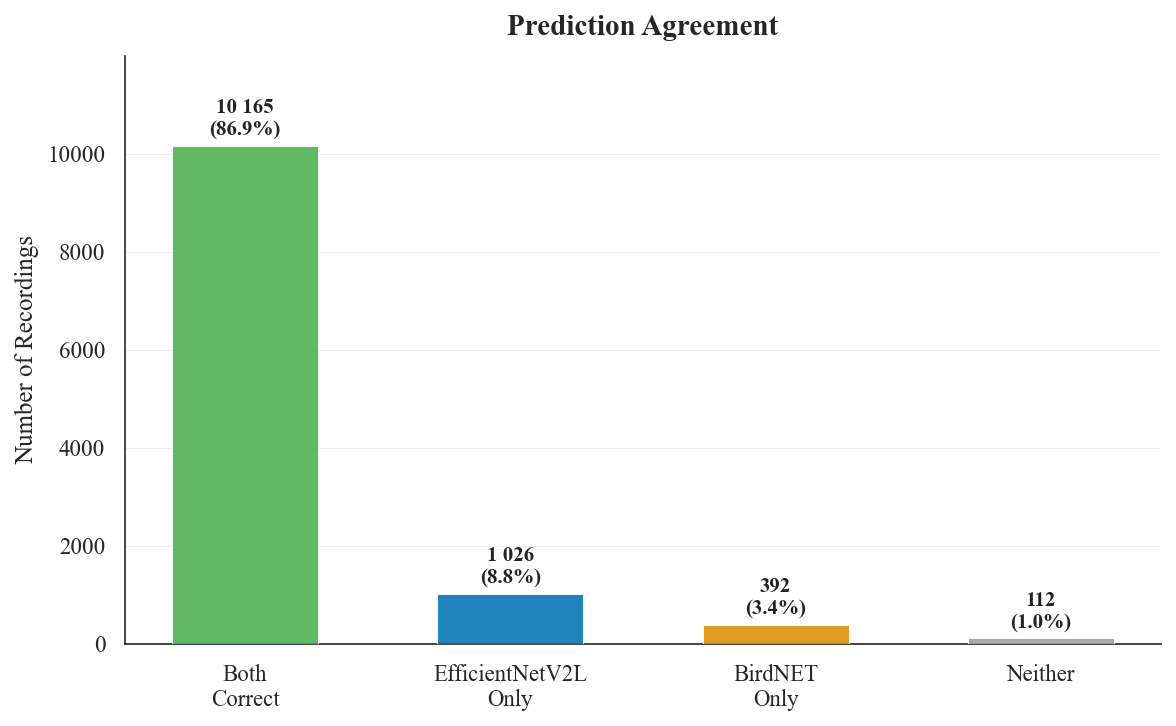

Overall agreement: 87.9%  |  n = 11 695  |  EfficientNetV2L-only correct: 1026  |  BirdNET-only correct: 392


In [4]:
# Prediction agreement between models
both   = int(( comp.correct_effnet &  comp.correct_birdnet).sum())
r_only = int(( comp.correct_effnet & ~comp.correct_birdnet).sum())
b_only = int((~comp.correct_effnet &  comp.correct_birdnet).sum())
none   = int((~comp.correct_effnet & ~comp.correct_birdnet).sum())

cats  = ["Both\nCorrect", "EfficientNetV2L\nOnly", "BirdNET\nOnly", "Neither"]
vals  = [both, r_only, b_only, none]
cols  = [vs.COLORS["success"], CR, CB, vs.COLORS["error_inter"]]
# thousands with thin space per journal guidelines
pcts  = [f"{v:,}\n({100*v/len(comp):.1f}%)".replace(",", " ") for v in vals]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cats, vals, color=cols, alpha=0.88, edgecolor="white", linewidth=0.5, zorder=3, width=0.55)
for bar, label in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.012,
            label, ha="center", va="bottom", fontsize=10, fontweight="semibold", color="#222222")
ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
ax.set_ylabel("Number of Recordings", fontsize=12)
ax.set_ylim(0, max(vals) * 1.18)
ax.set_title("Prediction Agreement", fontsize=14, fontweight="bold", pad=10)
ax.tick_params(axis="x", labelsize=11)
vs.despine(ax); fig.tight_layout()
vs.savefig_dual(fig, "cmp_agreement"); plt.show()
_n = f"{len(comp):,}".replace(",", " ")
print(f"Overall agreement: {100*(both+none)/len(comp):.1f}%  |  "
      f"n = {_n}  |  EfficientNetV2L-only correct: {r_only}  |  BirdNET-only correct: {b_only}")

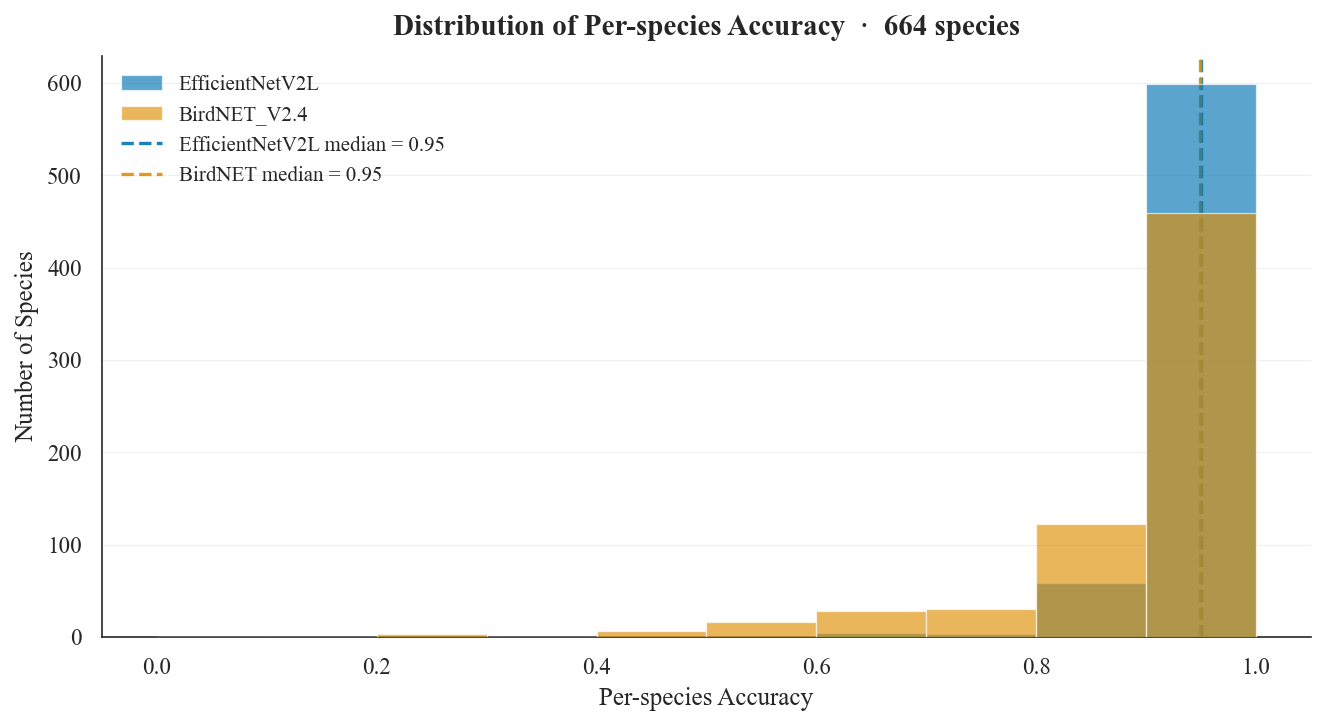

In [5]:
# Per-species accuracy distribution
acc_sp = comp.groupby("species_true").agg(
    n=("recording_id", "size"),
    acc_effnet=("correct_effnet", "mean"),
    acc_birdnet=("correct_birdnet", "mean"))

bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(acc_sp.acc_effnet,  bins=bins, alpha=0.65, label=RES,  color=CR,
        edgecolor="white", linewidth=0.6, zorder=3)
ax.hist(acc_sp.acc_birdnet, bins=bins, alpha=0.65, label=BIRD, color=CB,
        edgecolor="white", linewidth=0.6, zorder=3)

med_r = acc_sp.acc_effnet.median();  med_b = acc_sp.acc_birdnet.median()
ax.axvline(med_r, color=CR, lw=1.6, linestyle="--", alpha=0.9, label=f"EfficientNetV2L median = {med_r:.2f}")
ax.axvline(med_b, color=CB, lw=1.6, linestyle="--", alpha=0.9, label=f"BirdNET median = {med_b:.2f}")

ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
ax.set_xlabel("Per-species Accuracy", fontsize=12)
ax.set_ylabel("Number of Species", fontsize=12)
ax.set_title("Distribution of Per-species Accuracy  ·  664 species",
             fontsize=14, fontweight="bold", pad=10)
ax.legend(fontsize=10); vs.despine(ax); fig.tight_layout()
vs.savefig_dual(fig, "cmp_species_accuracy_dist"); plt.show()

/var/folders/79/pyscx8gj70dfw6hg9s51r1n00000gn/T/ipykernel_6924/3568906398.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Correct", "Incorrect"],
/var/folders/79/pyscx8gj70dfw6hg9s51r1n00000gn/T/ipykernel_6924/3568906398.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Correct", "Incorrect"],


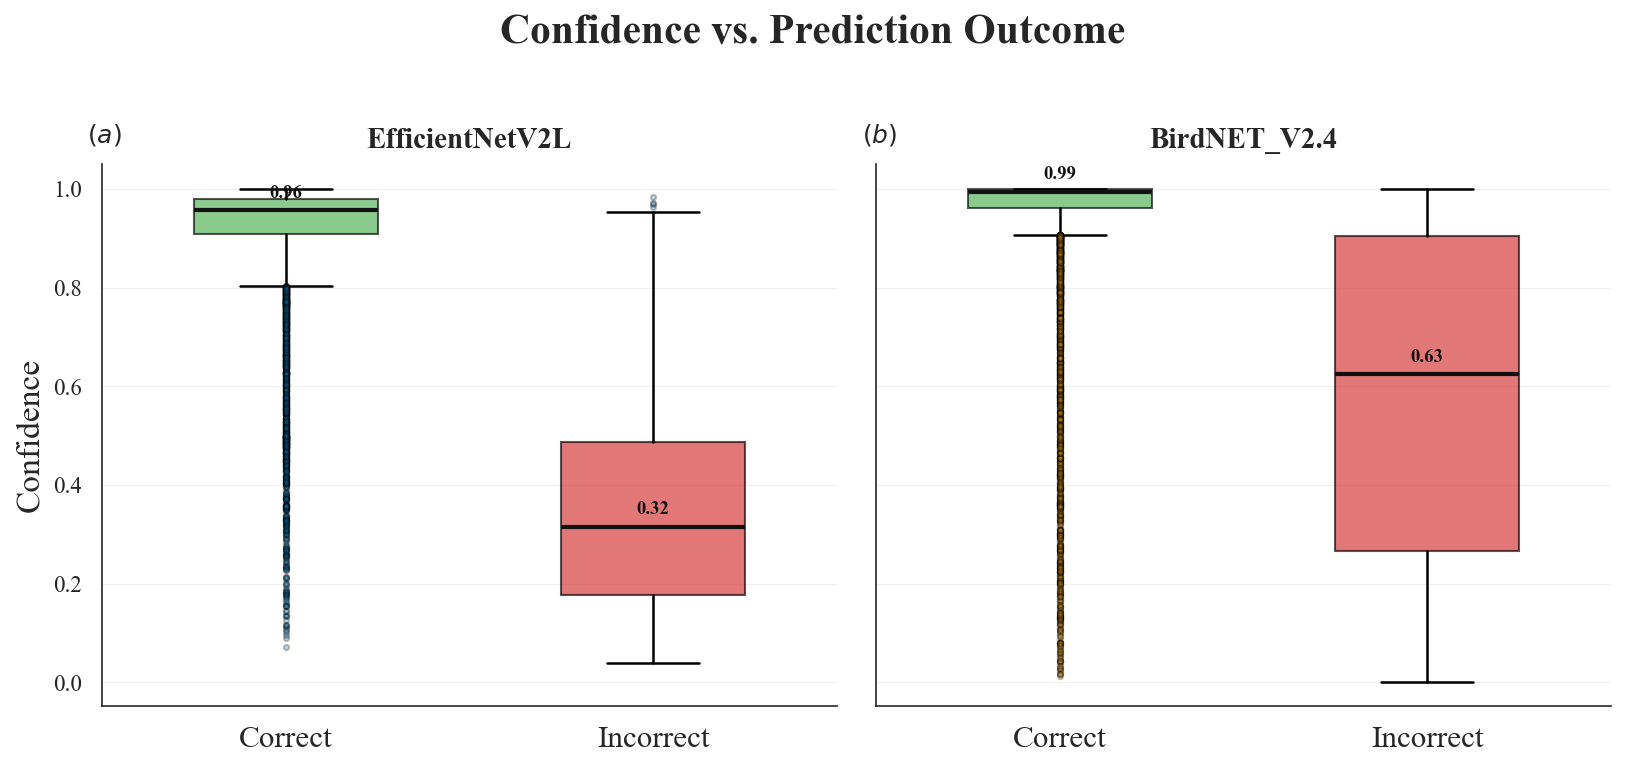

In [6]:
# Confidence vs. prediction outcome (do models know when they're right?)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
fig.subplots_adjust(wspace=0.06)

specs = [(RES,  "correct_effnet",  "confidence_effnet",  CR),
         (BIRD, "correct_birdnet", "confidence_birdnet", CB)]

for ax, (name, pcol, ccol, color) in zip(axes, specs):
    correct   = comp.loc[ comp[pcol], ccol].dropna()
    incorrect = comp.loc[~comp[pcol], ccol].dropna()
    data = [correct, incorrect]

    bp = ax.boxplot(data, labels=["Correct", "Incorrect"],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color="#111111", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=2.5,
                                    markerfacecolor=color, alpha=0.25,
                                    linestyle="none"))
    box_colors = [vs.COLORS["success"], vs.COLORS["error_intra"]]
    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c); patch.set_alpha(0.65)

    # medians as text annotation
    for i, grp in enumerate([correct, incorrect], 1):
        med = grp.median()
        ax.text(i, med + 0.025, f"{med:.2f}", ha="center", fontsize=9,
                fontweight="bold", color="#111111")

    ax.set_title(name, fontsize=14, fontweight="bold", pad=8)
    ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
    ax.tick_params(axis="x", labelsize=15)
    vs.despine(ax)

for i, ax in enumerate(axes):
    vs.panel_label(ax, "ab"[i])
axes[0].set_ylabel("Confidence", fontsize=16)
fig.suptitle("Confidence vs. Prediction Outcome",
             fontsize=20, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig('../fig/cmp_confidence_vs_correct.png', dpi=600, bbox_inches='tight')
plt.savefig('../fig/cmp_confidence_vs_correct.pdf', bbox_inches='tight')
plt.show()

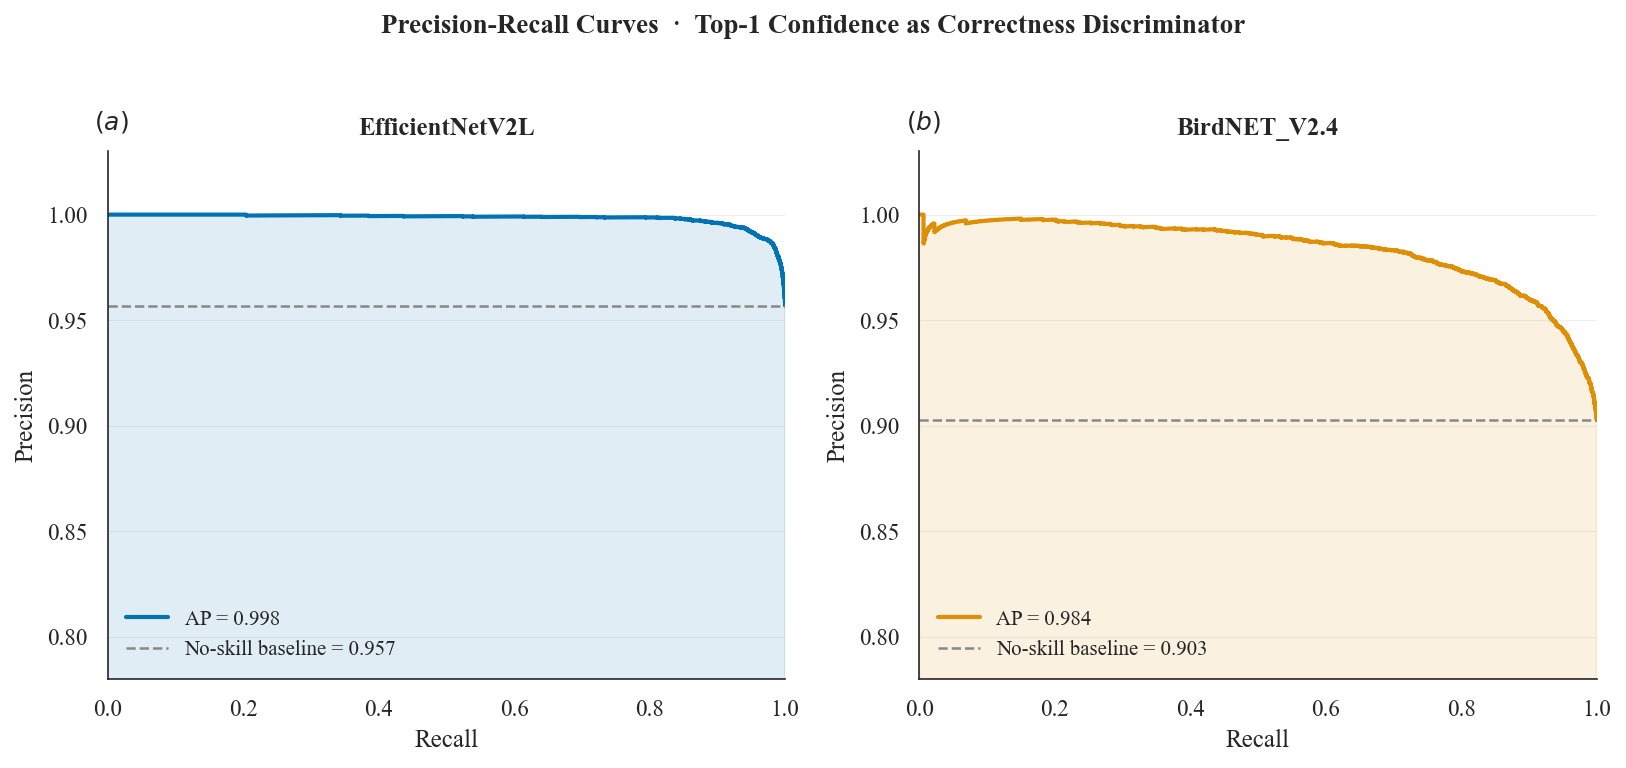

PR AUC (AP)  →  EfficientNetV2L: 0.9983  |  BirdNET: 0.9837
Lift over baseline  →  EfficientNetV2L: +0.041  |  BirdNET: +0.081


In [7]:
# Precision-Recall curves — top-1 confidence as correctness discriminator
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.subplots_adjust(wspace=0.08)

specs = [(RES,  "correct_effnet",  "confidence_effnet",  CR,  pr_auc_res),
         (BIRD, "correct_birdnet", "confidence_birdnet", CB, pr_auc_bird)]

for ax, (name, pcol, ccol, color, ap) in zip(axes, specs):
    prec, rec, _ = precision_recall_curve(comp[pcol].astype(int), comp[ccol])
    baseline = comp[pcol].mean()

    ax.fill_between(rec, prec, alpha=0.12, color=color, step="post")
    ax.step(rec, prec, where="post", color=color, lw=2.0, label=f"AP = {ap:.3f}")
    ax.axhline(baseline, color="#888888", lw=1.2, linestyle="--",
               label=f"No-skill baseline = {baseline:.3f}")

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_xlim(0, 1); ax.set_ylim(0.78, 1.03)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))
    ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
    ax.set_title(name, fontsize=12, fontweight="bold", pad=8)
    ax.legend(fontsize=10, loc="lower left")
    vs.despine(ax)

for i, ax in enumerate(axes):
    vs.panel_label(ax, "ab"[i])
fig.suptitle("Precision-Recall Curves  ·  Top-1 Confidence as Correctness Discriminator",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
vs.savefig_dual(fig, "cmp_pr_curves"); plt.show()
print(f"PR AUC (AP)  →  EfficientNetV2L: {pr_auc_res:.4f}  |  BirdNET: {pr_auc_bird:.4f}")
print("Lift over baseline  →  "
      f"EfficientNetV2L: +{pr_auc_res - comp.correct_effnet.mean():.3f}  |  "
      f"BirdNET: +{pr_auc_bird - comp.correct_birdnet.mean():.3f}")

## 2 · Por familia filogenética

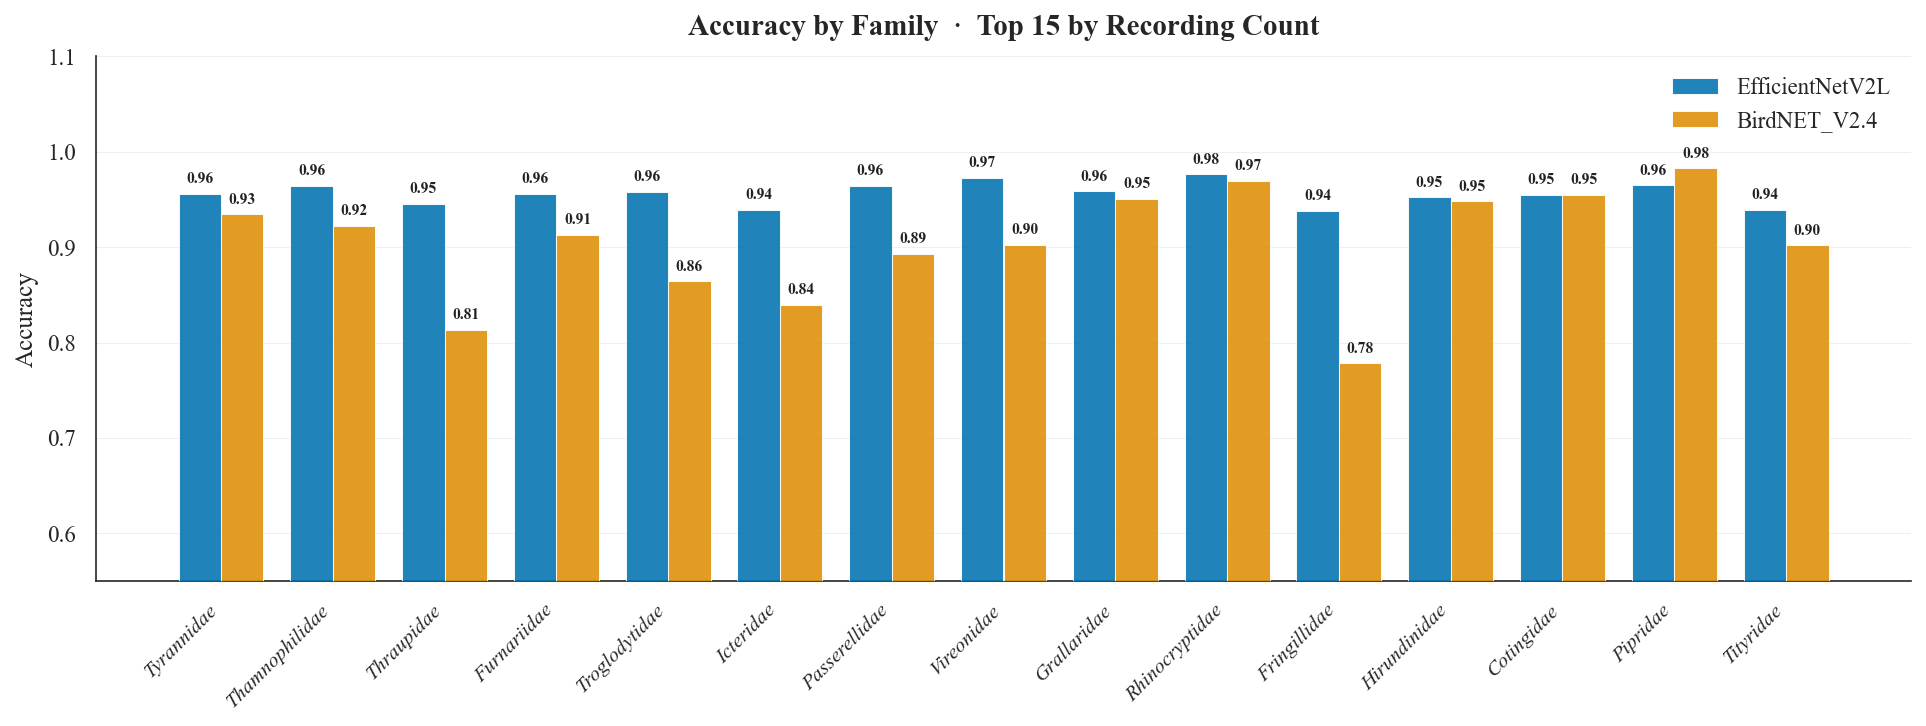

In [8]:
# Accuracy by family + relative advantage
fam = comp.groupby("family").agg(
    n=("recording_id", "size"),
    acc_effnet=("correct_effnet", "mean"),
    acc_birdnet=("correct_birdnet", "mean"))
fam["delta"] = fam.acc_effnet - fam.acc_birdnet
fam.sort_values("n", ascending=False).to_csv(os.path.join(DATA_DIR, "birdnet_vs_efficientnet_by_family.csv"))

topf = fam.sort_values("n", ascending=False).head(15)
xr = np.arange(len(topf)); w = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(xr - w/2, topf.acc_effnet,  w, label=RES,  color=CR, alpha=0.88,
            edgecolor="white", linewidth=0.5, zorder=3)
b2 = ax.bar(xr + w/2, topf.acc_birdnet, w, label=BIRD, color=CB, alpha=0.88,
            edgecolor="white", linewidth=0.5, zorder=3)

for bar, v in list(zip(b1, topf.acc_effnet)) + list(zip(b2, topf.acc_birdnet)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.007,
            f"{v:.2f}", ha="center", va="bottom", fontsize=7.5,
            fontweight="semibold", color="#222222")

ax.set_xticks(xr)
ax.set_xticklabels(topf.index, rotation=45, ha="right", fontsize=10, style="italic")
ax.set_ylim(0.55, 1.1)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy by Family  ·  Top 15 by Recording Count",
             fontsize=14, fontweight="bold", pad=10)
ax.legend(fontsize=11)
vs.despine(ax); fig.tight_layout()
vs.savefig_dual(fig, "cmp_family_accuracy"); plt.show()

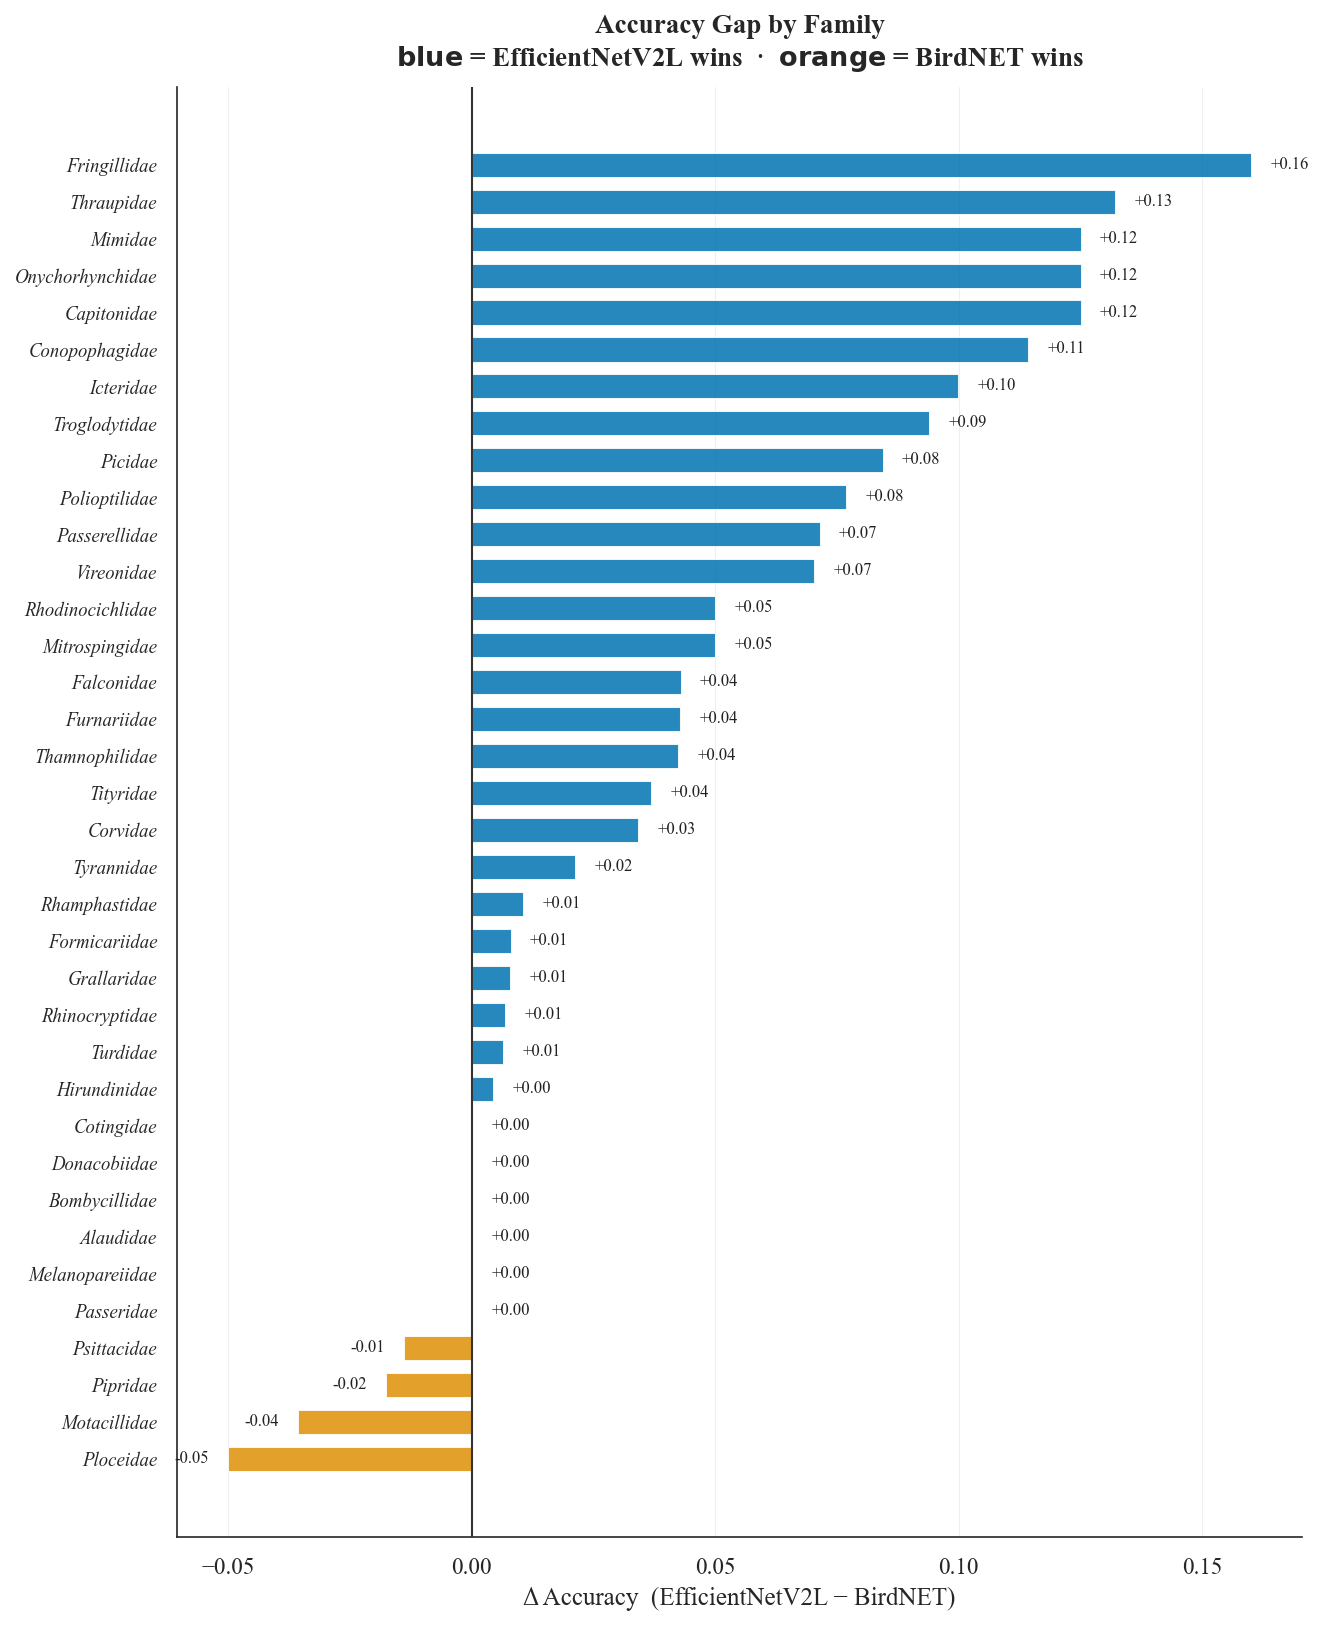

In [9]:
# Accuracy gap by family: Δ accuracy (EfficientNetV2L − BirdNET)
famd = fam.sort_values("delta")
bar_colors = [CR if d > 0 else CB for d in famd.delta]

fig, ax = plt.subplots(figsize=(9, 11))
bars = ax.barh(np.arange(len(famd)), famd.delta, color=bar_colors,
               alpha=0.85, edgecolor="white", linewidth=0.5, height=0.65, zorder=3)

# value labels
for bar, v in zip(bars, famd.delta):
    xpos = v + 0.004 if v >= 0 else v - 0.004
    ha   = "left"    if v >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{v:+.2f}",
            va="center", ha=ha, fontsize=8, color="#222222")

ax.axvline(0, color="#333333", lw=1.0, zorder=4)
ax.xaxis.grid(True, alpha=0.3, linewidth=0.5, zorder=0)
ax.set_yticks(np.arange(len(famd)))
ax.set_yticklabels(famd.index, fontsize=9, style="italic")
ax.set_xlabel("Δ Accuracy  (EfficientNetV2L − BirdNET)", fontsize=12)
ax.set_title("Accuracy Gap by Family\n"
             r"$\bf{blue}$ = EfficientNetV2L wins  ·  $\bf{orange}$ = BirdNET wins",
             fontsize=13, fontweight="bold", pad=10)
vs.despine(ax); fig.tight_layout()
vs.savefig_dual(fig, "cmp_family_delta"); plt.show()

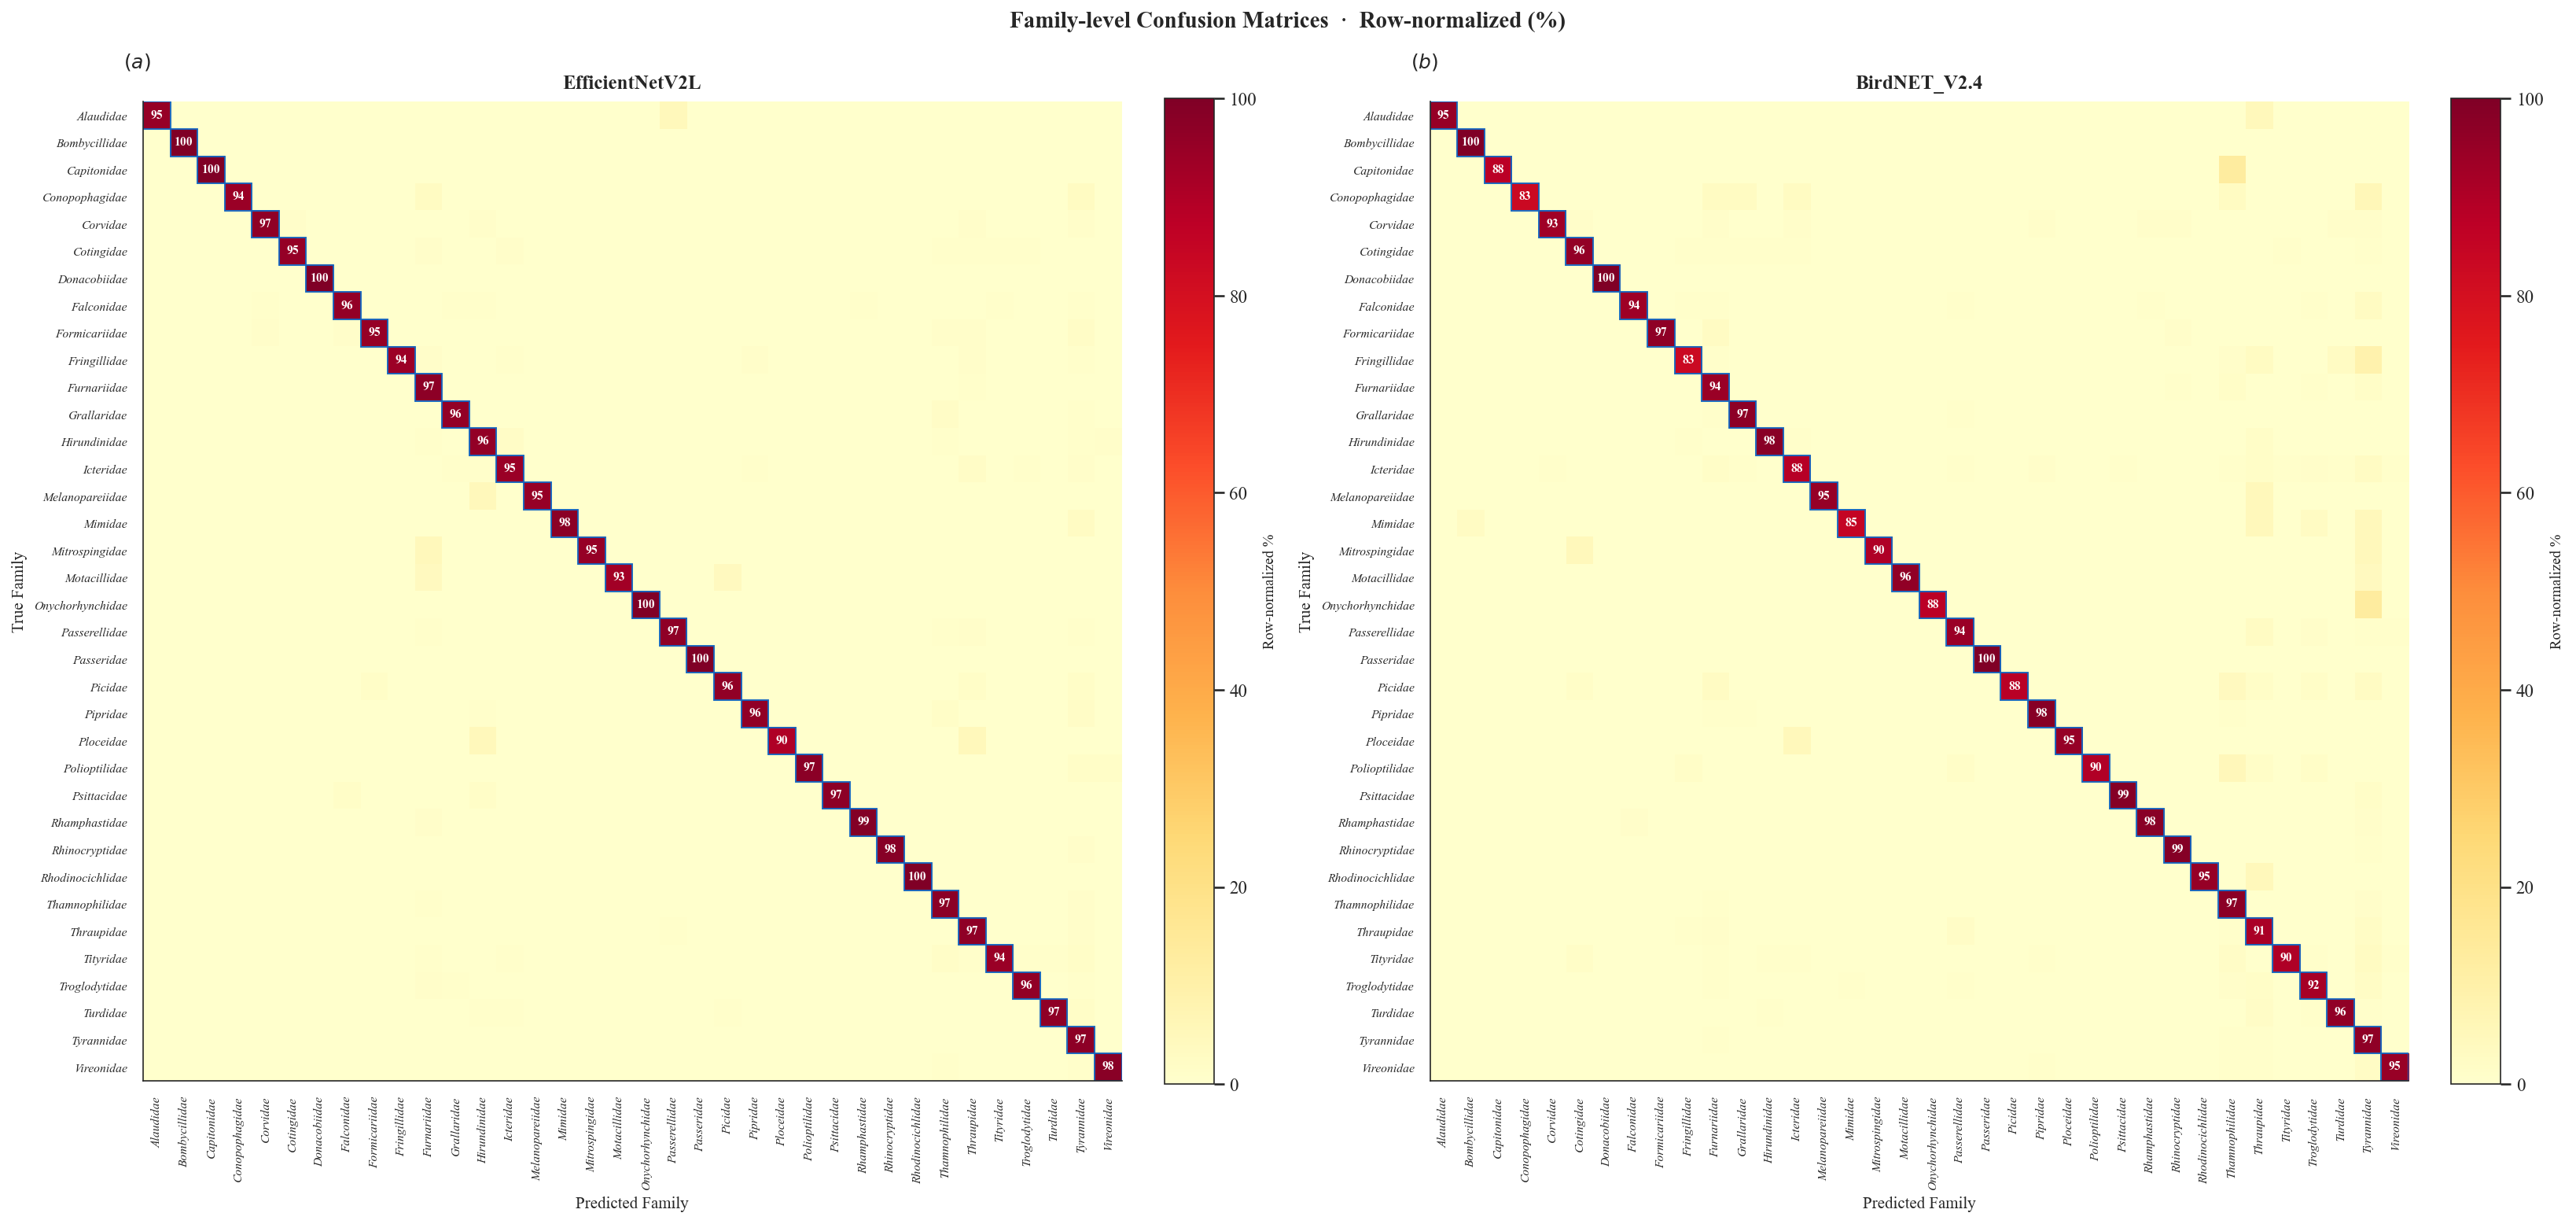

Mean diagonal (family-level recall):  EfficientNetV2L = 96.6%  |  BirdNET = 93.7%


In [10]:
# Family-level confusion matrices (row-normalized %)
families = sorted(comp.family.dropna().unique())
fidx = {f: i for i, f in enumerate(families)}

def family_confusion(pred_col):
    tf = comp.family.map(fidx)
    pf = comp[pred_col].map(lambda s: bu.family_of(s, gf)).map(fidx)
    m  = tf.notna() & pf.notna()
    cm = confusion_matrix(tf[m].astype(int), pf[m].astype(int), labels=range(len(families)))
    return cm / cm.sum(1, keepdims=True).clip(min=1) * 100

cms = {RES: family_confusion("species_pred_effnet"), BIRD: family_confusion("species_pred_birdnet")}

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, name in zip(axes, [RES, BIRD]):
    cmn = cms[name]
    im  = ax.imshow(cmn, cmap=vs.CMAP_CONFUSION, vmin=0, vmax=100, aspect="equal")
    ax.set_xticks(range(len(families)))
    ax.set_xticklabels(families, rotation=90, fontsize=7.5, style="italic")
    ax.set_yticks(range(len(families)))
    ax.set_yticklabels(families, fontsize=7.5, style="italic")
    for i in range(len(families)):
        ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1,
                               fill=False, edgecolor=vs.COLORS["highlight"], lw=0.9))
        v = cmn[i, i]
        ax.text(i, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                fontweight="bold", color="white" if v > 55 else "black")
    ax.set_title(f"{name}", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Predicted Family", fontsize=10)
    ax.set_ylabel("True Family", fontsize=10)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Row-normalized %", fontsize=9)

for i, ax in enumerate(axes):
    vs.panel_label(ax, "ab"[i])
fig.suptitle("Family-level Confusion Matrices  ·  Row-normalized (%)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
vs.savefig_dual(fig, "cmp_family_confusion"); plt.show()
print("Mean diagonal (family-level recall):  "
      f"EfficientNetV2L = {np.diag(cms[RES]).mean():.1f}%  |  BirdNET = {np.diag(cms[BIRD]).mean():.1f}%")

## 3 · Por género

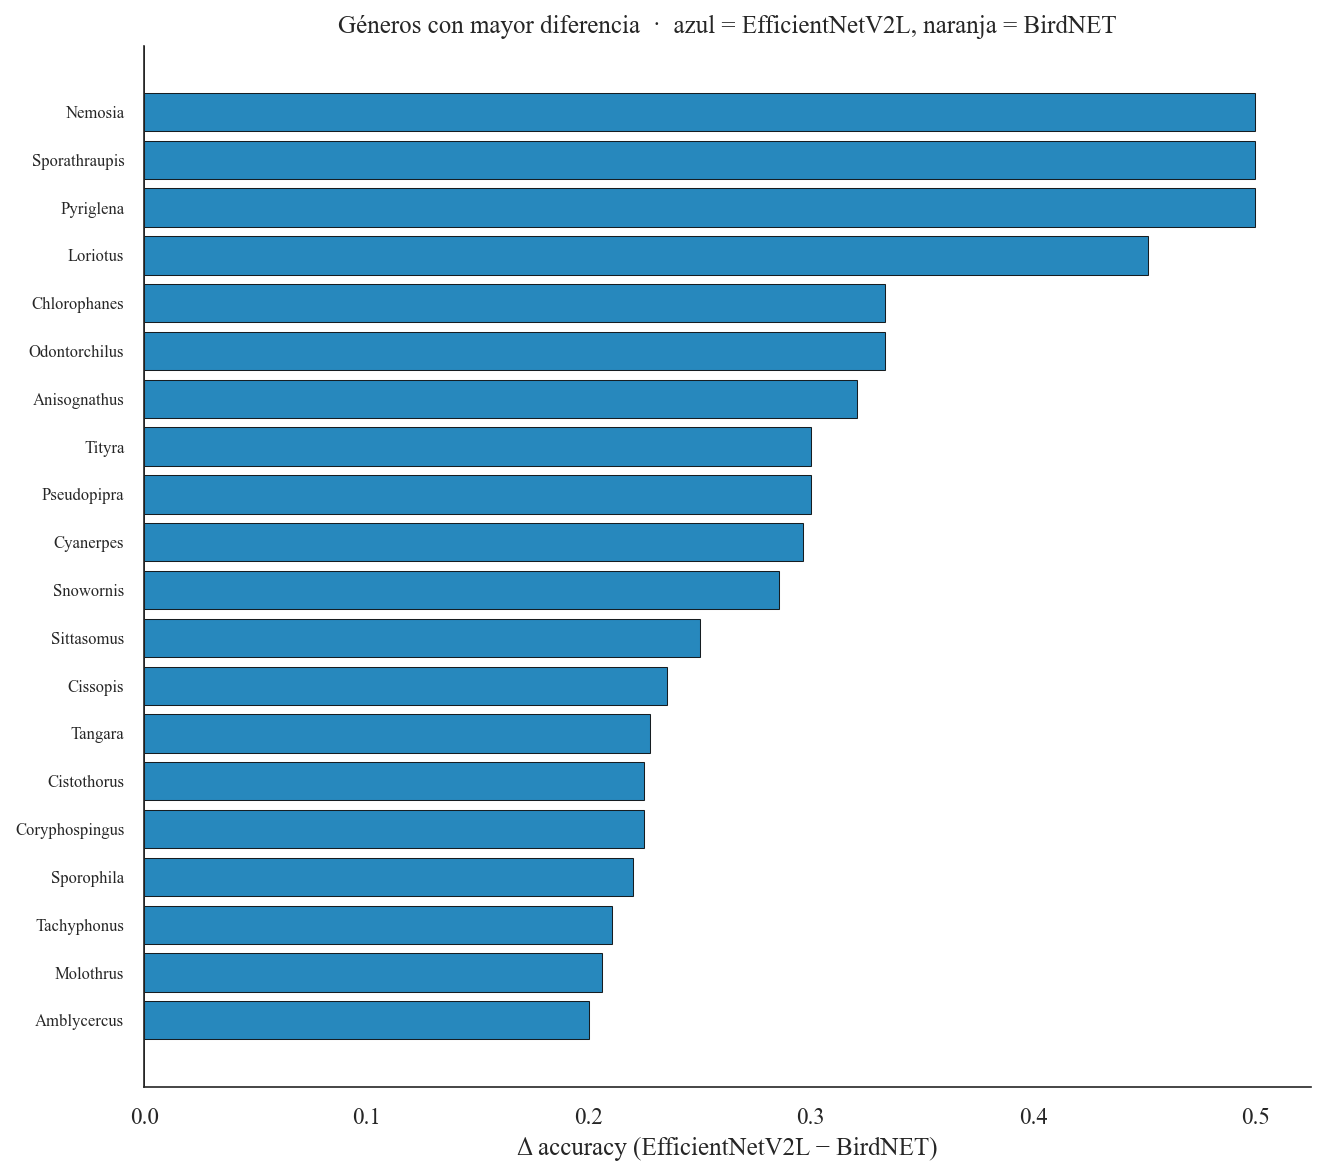

In [11]:
# Géneros con mayor diferencia entre modelos (mínimo 2 grabaciones)
gen = comp.groupby("genus").agg(
    n=("recording_id", "size"),
    acc_effnet=("correct_effnet", "mean"),
    acc_birdnet=("correct_birdnet", "mean"))
gen = gen[gen.n >= 2].copy()
gen["delta"] = gen.acc_effnet - gen.acc_birdnet
top = gen.reindex(gen.delta.abs().sort_values(ascending=False).index).head(20).sort_values("delta")

colors = [CR if d > 0 else CB for d in top.delta]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(np.arange(len(top)), top.delta, color=colors, edgecolor="black", linewidth=0.5, alpha=0.85)
ax.set_yticks(np.arange(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Δ accuracy (EfficientNetV2L − BirdNET)")
ax.set_title("Géneros con mayor diferencia  ·  azul = EfficientNetV2L, naranja = BirdNET")
vs.despine(ax); fig.tight_layout()
vs.savefig_dual(fig, "cmp_genus_delta"); plt.show()

## 4 · Insights: dónde gana cada modelo

In [12]:
# Resumen ejecutivo
from scipy.stats import pointbiserialr
print("=" * 64)
print("RESUMEN COMPARATIVO · EfficientNetV2L vs BirdNET V2.4 (recording-level)")
print("=" * 64)
print(summary.round(4).to_string())
print(f"\nGrabaciones: {len(comp)} | especies: {comp.species_true.nunique()} | familias: {comp.family.nunique()}")
print(f"Concordancia -> ambos: {both} | solo EfficientNetV2L: {r_only} | solo BirdNET: {b_only} | ninguno: {none}")
try:
    rr = pointbiserialr(comp.correct_effnet.astype(int),  comp.confidence_effnet)[0]
    rb = pointbiserialr(comp.correct_birdnet.astype(int), comp.confidence_birdnet)[0]
    print(f"Correlación confianza-acierto (point-biserial): EfficientNetV2L r={rr:.2f} | BirdNET r={rb:.2f}")
except Exception as e:
    print("correlación no disponible:", e)
print(f"PR AUC (AP, top-1 conf): EfficientNetV2L={pr_auc_res:.4f} | BirdNET={pr_auc_bird:.4f}")
gan_res = int((fam.delta > 0).sum()); gan_bird = int((fam.delta < 0).sum())
print(f"Familias donde gana EfficientNetV2L: {gan_res} | donde gana BirdNET: {gan_bird} | empate: {int((fam.delta==0).sum())}")
print("\nFiguras en fig/: cmp_global_metrics, cmp_agreement, cmp_species_accuracy_dist,")
print("  cmp_confidence_vs_correct, cmp_pr_curves, cmp_family_accuracy, cmp_family_delta, cmp_family_confusion, cmp_genus_delta")
print("Tablas en src/data/: birdnet_vs_efficientnet_global_metrics.csv (incluye pr_auc), _by_family.csv, _by_species.csv")

RESUMEN COMPARATIVO · EfficientNetV2L vs BirdNET V2.4 (recording-level)
                 accuracy  f1_macro  precision_macro  recall_macro  f1_weighted  precision_weighted  recall_weighted  pr_auc  roc_auc
EfficientNetV2L    0.9569    0.9524           0.9566        0.9508       0.9570              0.9595           0.9569  0.9983   0.9672
BirdNET_V2.4       0.9027    0.8995           0.9122        0.8992       0.9005              0.9093           0.9027  0.9837   0.8813

Grabaciones: 11695 | especies: 664 | familias: 36
Concordancia -> ambos: 10165 | solo EfficientNetV2L: 1026 | solo BirdNET: 392 | ninguno: 112
Correlación confianza-acierto (point-biserial): EfficientNetV2L r=0.62 | BirdNET r=0.52
PR AUC (AP, top-1 conf): EfficientNetV2L=0.9983 | BirdNET=0.9837
Familias donde gana EfficientNetV2L: 26 | donde gana BirdNET: 4 | empate: 6

Figuras en fig/: cmp_global_metrics, cmp_agreement, cmp_species_accuracy_dist,
  cmp_confidence_vs_correct, cmp_pr_curves, cmp_family_accuracy, cmp_fami